In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 

%matplotlib inline
sns.set_theme(style="whitegrid")

In [69]:
df = pd.read_csv("housing.csv")

In [70]:
df.head(10)
df.tail(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [71]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (20640, 10)


In [72]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [73]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [75]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical)
print("Categorical columns:", categorical)

Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


C:\Users\shouvik.b\AppData\Local\Temp\ipykernel_24028\1188317209.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=["object"]).columns.tolist()


In [76]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(numerical_columns)

print()

print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')

Categorical Columns:
Index(['ocean_proximity'], dtype='str')


In [77]:
df.describe()
df.describe(include="object")

C:\Users\shouvik.b\AppData\Local\Temp\ipykernel_24028\905123212.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [121]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909,5.383836,0.213645,2.931212
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874,1.652706,0.061835,0.821141
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.037151,0.692308
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,4.440716,0.175225,2.429741
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129,0.203159,2.818116
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,6.052381,0.240126,3.282261
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,20.000000,1.000000,10.000000


In [78]:
df.describe()
df.describe(include="str")

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


# Part 2 – Data Cleaning

## Objective
Prepare the dataset for analysis by identifying and handling missing values, duplicate records, incorrect values, and verifying the correctness of feature data types.

In [79]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

total_bedrooms has 207 missing values (~1% of rows). I fill them with the median rather than the mean because total_bedrooms is right-skewed (a few block groups have very large totals), and the median is robust to those outliers whereas the mean would be pulled upward. I fill rather than drop because 207 rows still carry useful information in their other 9 columns, and dropping them isn't necessary for so small a fraction.

In [80]:
median_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)

print("Missing in total_bedrooms after fill:", df["total_bedrooms"].isnull().sum())

Missing in total_bedrooms after fill: 0


In [81]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64



The dataset contained 207 missing values in the `total_bedrooms` column.

Instead of removing these rows, the missing values were replaced using the **median** of the `total_bedrooms` column.

The median was chosen because this feature is typically skewed by districts with very large numbers of bedrooms. Unlike the mean, the median is less affected by outliers and therefore provides a more robust estimate.

In [82]:
df.select_dtypes(include='number').columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')

In [83]:
df.select_dtypes(exclude='number').columns

Index(['ocean_proximity'], dtype='str')

In [84]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (20640, 10)



The dataset was checked for duplicate records using `df.duplicated().sum()`.

No duplicate rows were found (or all duplicate rows were removed successfully).

Therefore, the dataset contains only unique observations.

In [85]:
df.min(numeric_only=True)

longitude              -124.3500
latitude                 32.5400
housing_median_age        1.0000
total_rooms               2.0000
total_bedrooms            1.0000
population                3.0000
households                1.0000
median_income             0.4999
median_house_value    14999.0000
dtype: float64

In [86]:
print("Negative total_rooms:", (df["total_rooms"] < 0).sum())

print("Negative total_bedrooms:", (df["total_bedrooms"] < 0).sum())

print("Negative population:", (df["population"] < 0).sum())

print("Negative households:", (df["households"] < 0).sum())

print("Negative median_income:", (df["median_income"] < 0).sum())

print("Negative housing_median_age:", (df["housing_median_age"] < 0).sum())

Negative total_rooms: 0
Negative total_bedrooms: 0
Negative population: 0
Negative households: 0
Negative median_income: 0
Negative housing_median_age: 0


In [87]:
cols_to_check = ["housing_median_age", "total_rooms", "total_bedrooms",
                 "population", "households", "median_income", "median_house_value"]

for col in cols_to_check:
    n_bad = (df[col] <= 0).sum()
    print(f"{col}: {n_bad} values <= 0")

housing_median_age: 0 values <= 0
total_rooms: 0 values <= 0
total_bedrooms: 0 values <= 0
population: 0 values <= 0
households: 0 values <= 0
median_income: 0 values <= 0
median_house_value: 0 values <= 0


In [88]:
(df["median_house_value"] == 0).sum()

np.int64(0)

In [89]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [90]:
print("Final cleaned shape:", df.shape)
print("Total missing values remaining:", df.isnull().sum().sum())

Final cleaned shape: (20640, 10)
Total missing values remaining: 0


In [91]:
df.duplicated().sum()

df.min(numeric_only=True)

(df["median_house_value"] == 0).sum()

df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [92]:
df.shape

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Conclusion of Part 2

The dataset was cleaned successfully before analysis.

- Missing values were checked in all columns.
- The `total_bedrooms` column contained 207 missing values, which were replaced using the median value because the median is more robust to skewed data and outliers than the mean.
- Duplicate rows were checked, and no duplicate records were found.
- The dataset was examined for incorrect or impossible values, such as negative room counts, negative population, negative income, and zero house values. No such values were found.
- The data types of all features were verified and found to be appropriate.
- The cleaned dataset is now ready for exploratory data analysis and machine learning.

# Part 3 – Exploratory Data Analysis (EDA)

## Objective

The objective of Exploratory Data Analysis (EDA) is to understand the dataset by computing descriptive statistics and creating visualizations. EDA helps identify data distributions, relationships between variables, outliers, and patterns before applying machine learning models.

In [93]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()

summary_stats = pd.DataFrame({
    "Mean":   df[numerical].mean(),
    "Median": df[numerical].median(),
    "Mode":   df[numerical].mode().iloc[0]   # mode() can return multiple rows; take the first
})
summary_stats

,Mean,Median,Mode
longitude,-119.569704,-118.4900,-118.310
latitude,35.631861,34.2600,34.060
housing_median_age,28.639486,29.0000,52.000
total_rooms,2635.763081,2127.0000,1527.000
total_bedrooms,536.838857,435.0000,435.000
population,1425.476744,1166.0000,891.000
households,499.539680,409.0000,306.000
median_income,3.870671,3.5348,3.125
median_house_value,206855.816909,179700.0000,500001.000


In [94]:
key_features = ["median_income", "median_house_value", "total_rooms",
                "housing_median_age", "population"]

Q1 = df[key_features].quantile(0.25)
Q3 = df[key_features].quantile(0.75)

dispersion = pd.DataFrame({
    "Variance": df[key_features].var(),
    "Std Dev":  df[key_features].std(),
    "IQR":      Q3 - Q1
})
dispersion

,Variance,Std Dev,IQR
median_income,3.609323e+00,1.899822,2.17985
median_house_value,1.331615e+10,115395.615874,145125.00000
total_rooms,4.759445e+06,2181.615252,1700.25000
housing_median_age,1.583963e+02,12.585558,19.00000
population,1.282470e+06,1132.462122,938.00000


In [95]:
skew_table = pd.DataFrame({
    "Mean":   df[numerical].mean(),
    "Median": df[numerical].median(),
})
skew_table["Mean - Median"] = skew_table["Mean"] - skew_table["Median"]
skew_table["Skew (pandas)"] = df[numerical].skew()
skew_table

,Mean,Median,Mean - Median,Skew (pandas)
longitude,-119.569704,-118.4900,-1.079704,-0.297801
latitude,35.631861,34.2600,1.371861,0.465953
housing_median_age,28.639486,29.0000,-0.360514,0.060331
total_rooms,2635.763081,2127.0000,508.763081,4.147343
total_bedrooms,536.838857,435.0000,101.838857,3.481141
population,1425.476744,1166.0000,259.476744,4.935858
households,499.539680,409.0000,90.539680,3.410438
median_income,3.870671,3.5348,0.335871,1.646657
median_house_value,206855.816909,179700.0000,27155.816909,0.977763


In [96]:
full_summary = df[numerical].describe().T   # .T transposes so features are rows
full_summary["mode"] = df[numerical].mode().iloc[0]
full_summary["variance"] = df[numerical].var()
full_summary["IQR"] = df[numerical].quantile(0.75) - df[numerical].quantile(0.25)
full_summary["skew"] = df[numerical].skew()
full_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,mode,variance,IQR,skew
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31,-118.31,4.010000e+00,3.79,-0.30
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95,34.06,4.560000e+00,3.78,0.47
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00,52.00,1.584000e+02,19.00,0.06
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00,1527.00,4.759445e+06,1700.25,4.15
total_bedrooms,20640.0,536.84,419.39,1.00,297.00,435.00,643.25,6445.00,435.00,1.758895e+05,346.25,3.48
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00,891.00,1.282470e+06,938.00,4.94
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00,306.00,1.461760e+05,325.00,3.41
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00,3.12,3.610000e+00,2.18,1.65
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00,500001.00,1.331615e+10,145125.00,0.98


visualisation

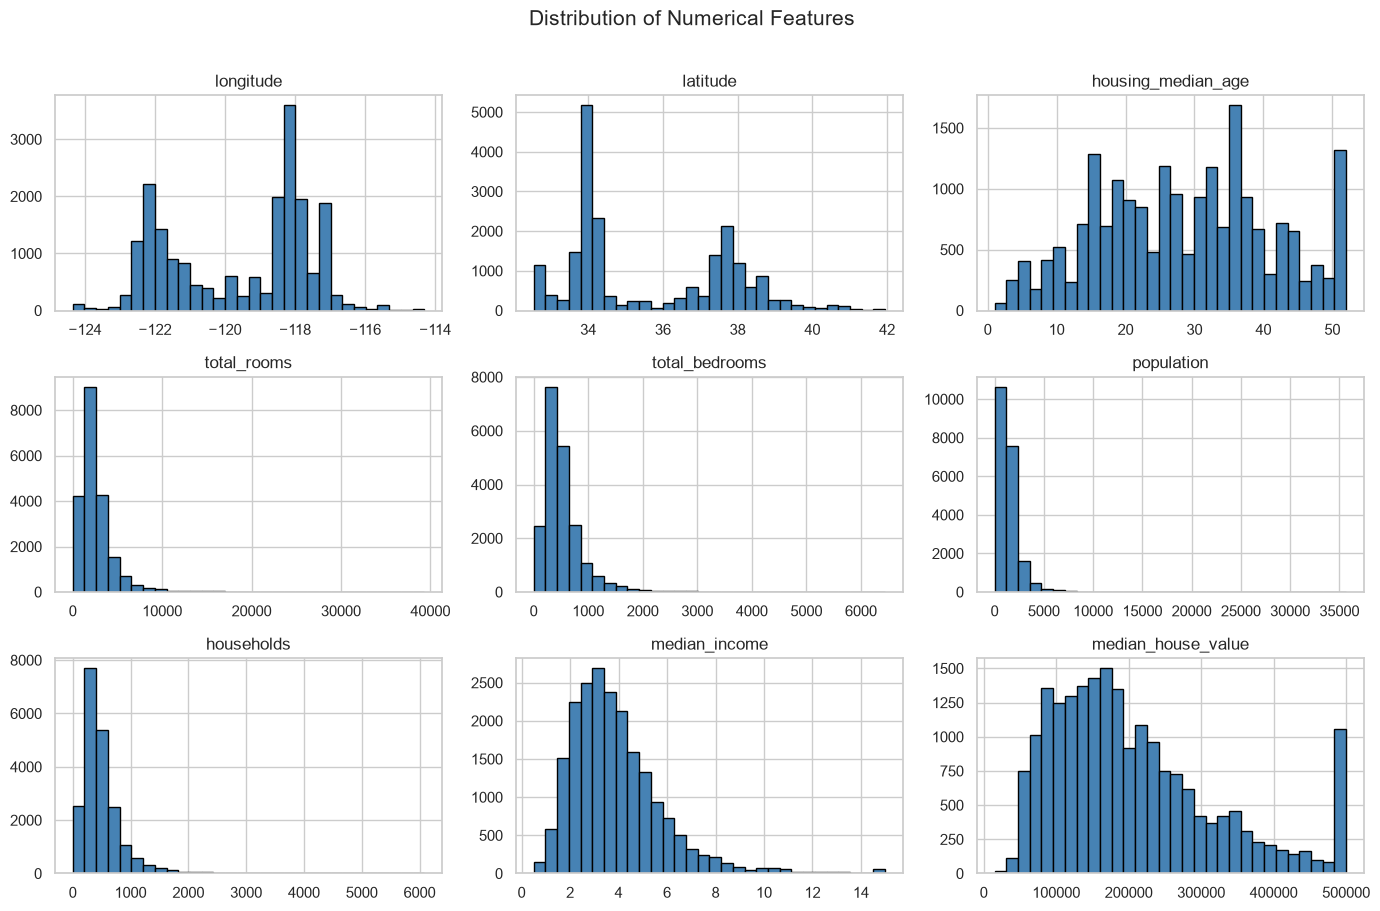

In [124]:
df[numerical].hist(figsize=(14, 9), bins=30, color="steelblue", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

explanations

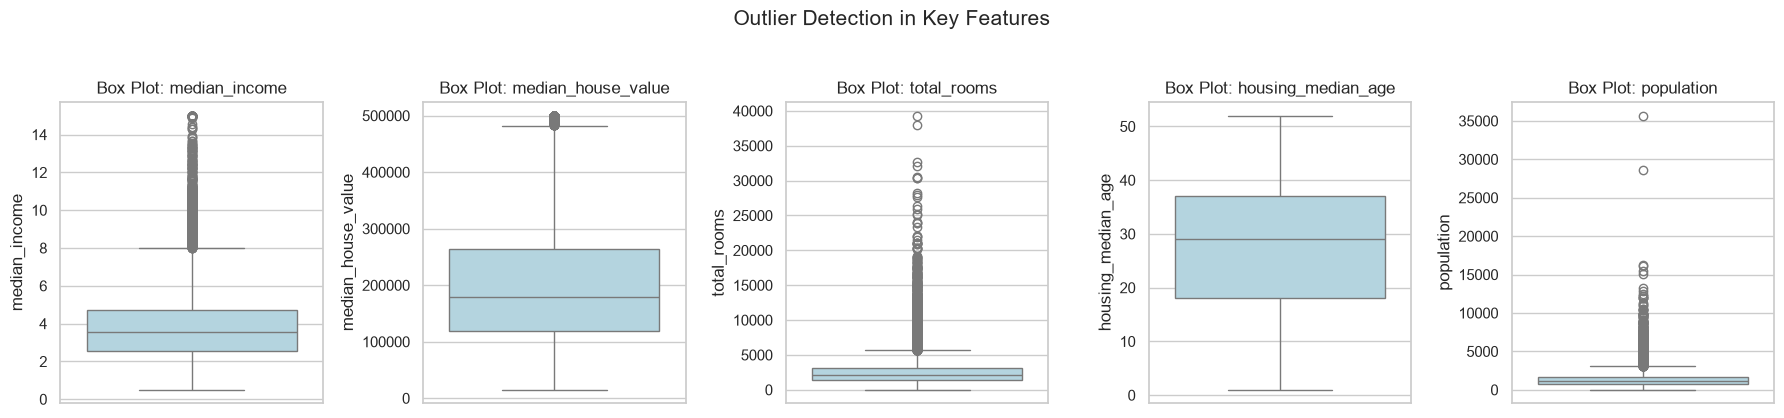

In [125]:
fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))

for ax, col in zip(axes, key_features):
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(f"Box Plot: {col}")
    ax.set_ylabel(col)

plt.suptitle("Outlier Detection in Key Features", fontsize=15, y=1.04)
plt.tight_layout()
plt.show()

explanation

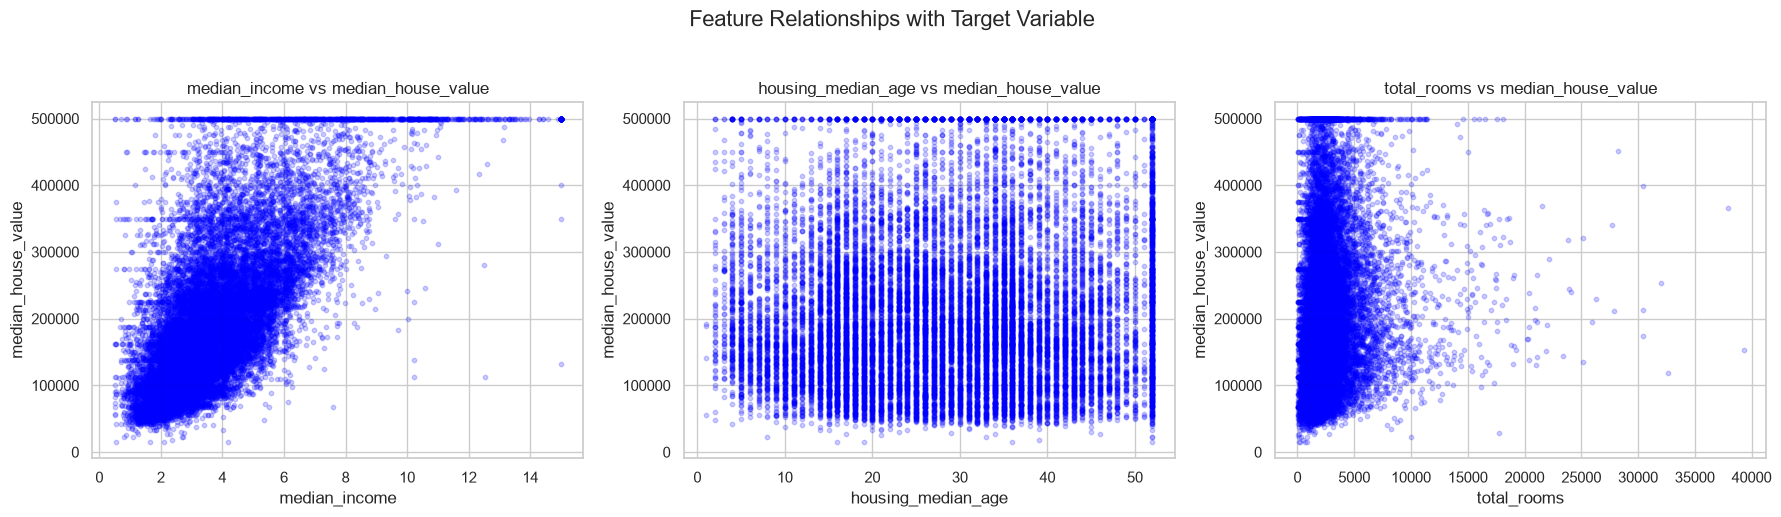

In [99]:
scatter_features = ["median_income", "housing_median_age", "total_rooms"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, scatter_features):
    ax.scatter(df[col], df["median_house_value"], alpha=0.2, color="blue", s=10)
    ax.set_title(f"{col} vs median_house_value")
    ax.set_xlabel(col)
    ax.set_ylabel("median_house_value")

plt.suptitle("Feature Relationships with Target Variable", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

explanation

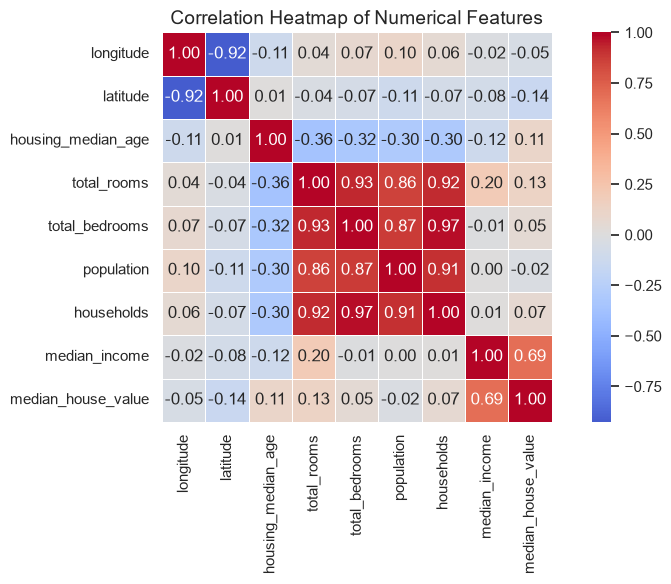

In [122]:
plt.figure(figsize=(9, 6))
corr = df[numerical].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

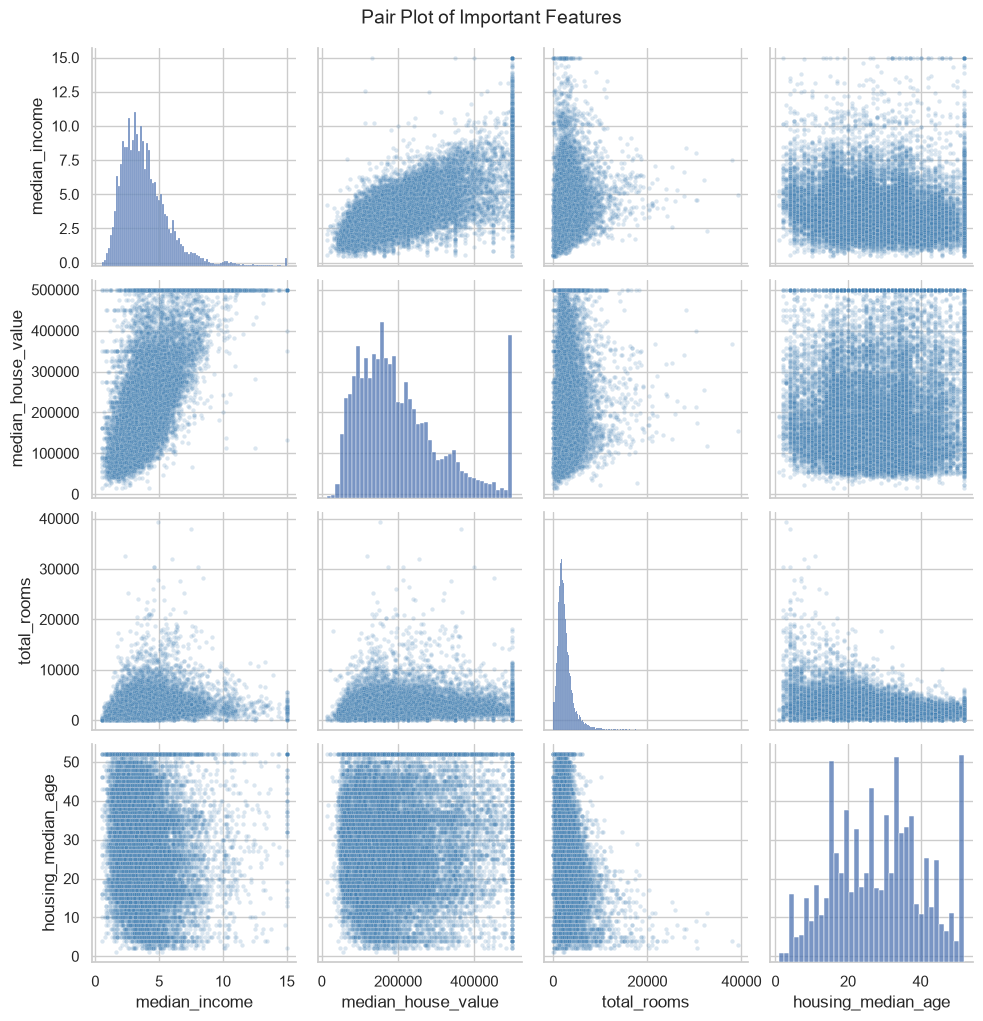

In [101]:
important = ["median_income", "median_house_value", "total_rooms", "housing_median_age"]

sns.pairplot(df[important], diag_kind="hist",
             plot_kws={"alpha": 0.2, "s": 10, "color": "steelblue"})
plt.suptitle("Pair Plot of Important Features", y=1.02, fontsize=14)
plt.show()

# Part 4 – Insights & Observations

## Objective

The purpose of this section is to summarize the important findings obtained from the Exploratory Data Analysis (EDA). These observations are based on the summary statistics and visualizations created in Part 3.

**Correlations with the target**

1. **median_income is the strongest predictor** of median_house_value (r = 0.69 on the heatmap), by a wide margin. Wealthier areas have more expensive housing, flagging income as the single most useful feature for prediction.
2. **The weakest target correlations are population (−0.02), households (0.07), and total_bedrooms (0.05).** Individually these barely move with house value, suggesting raw counts are poor standalone predictors.

**Outliers**

3. **total_rooms and population have heavy high-side outliers** — compressed boxes near zero with long trails past 30,000 rooms and 35,000 people.
4. **median_income has many outliers above ~8**, corresponding to a small number of high-income blocks.
5. **housing_median_age has no outliers** — its whiskers reach both extremes cleanly, meaning age is naturally bounded and well-behaved.

**Distribution shapes**

6. **total_rooms, total_bedrooms, population, and households are all strongly right-skewed**, because they scale with block-group size. This confirmed the median was the correct fill choice for missing total_bedrooms in Part 2.
7. **median_income is moderately right-skewed but roughly bell-shaped**, peaking around 3–4 (tens of thousands of dollars).
8. **longitude and latitude are bimodal**, corresponding to California's two population centers (the Bay Area and the Los Angeles/San Diego region).

**Trends and patterns**

9. **The income–value relationship fans outward** in the pair plot: as income rises, house value rises but its spread widens.
10. **The four size features are severely multicollinear** (r = 0.86 to 0.97, e.g. total_bedrooms ↔ households = 0.97), so a regression should use engineered ratios rather than all four raw totals.

**Data quality issues**

11. **median_house_value is capped at $500,001** — a tall isolated spike at the right edge of its histogram and a hard horizontal line in the pair plot. Any block worth more was clipped.
12. **median_income is capped at ~15**, another artificial truncation introduced when the dataset was built.

## Part 5 — Simple Linear Regression

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

I choose median_income as the single predictor because it has the highest correlation with median_house_value (r = 0.69 from the Part 3 heatmap) — far stronger than any other feature. For simple linear regression, the feature most linearly related to the target gives the best single-variable model.

In [103]:
X = df[["median_income"]]
y = df["median_house_value"]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:", X_test.shape[0], "rows")

Training set: 16512 rows
Test set: 4128 rows


In [105]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41933.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.446e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [106]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (coefficient): {slope:.2f}")
print(f"Intercept: {intercept:.2f}")

Slope (coefficient): 41933.85
Intercept: 44459.73


The slope of 41933.85 means that for every 1-unit increase in median_income (i.e. $10,000 of income, since income is in tens of thousands), the predicted median house value rises by about $41933.85. The intercept of 44459.73 is the model's predicted house value when income is zero — not physically meaningful here, just where the line crosses the axis.

In [107]:
y_pred = model.predict(X_test)

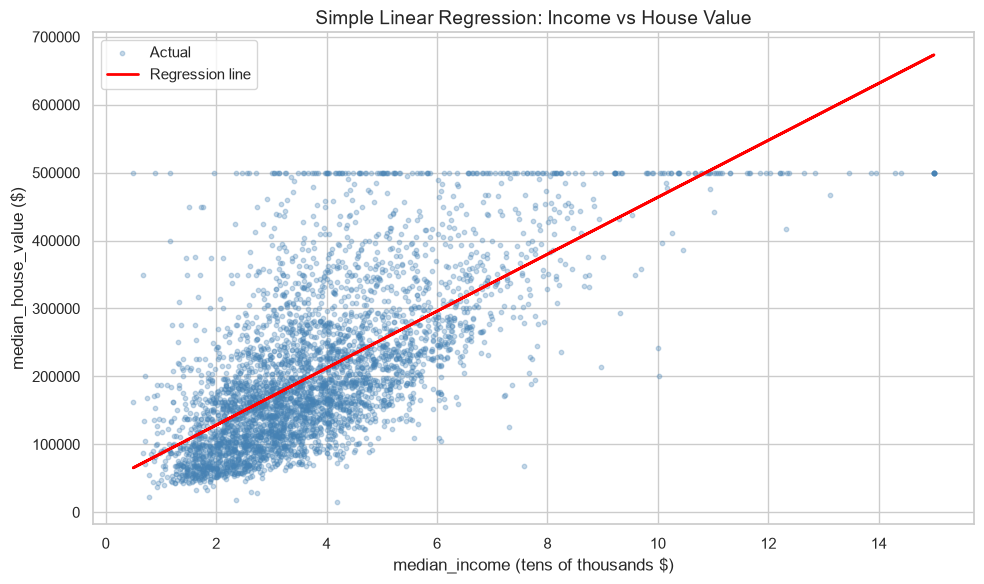

In [108]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.3, color="steelblue", label="Actual", s=10)
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression line")
plt.title("Simple Linear Regression: Income vs House Value", fontsize=14)
plt.xlabel("median_income (tens of thousands $)")
plt.ylabel("median_house_value ($)")
plt.legend()
plt.tight_layout()
plt.show()

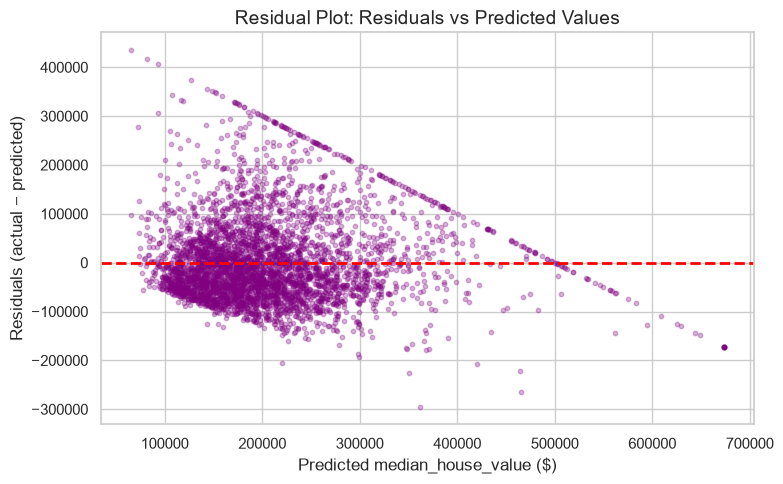

In [123]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color="purple", s=10)
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.title("Residual Plot: Residuals vs Predicted Values", fontsize=14)
plt.xlabel("Predicted median_house_value ($)")
plt.ylabel("Residuals (actual − predicted)")
plt.tight_layout()
plt.show()

In [110]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

R² Score: 0.4589
MAE:  62,990.87
RMSE: 84,209.01


With R² ≈ 0.46, the model explains about 46% of the variation in house value using income alone — a moderate result. It's a reasonable single-feature baseline given that income was the strongest predictor, but the MAE of ~$63,000 shows predictions are often far off. Two structural problems limit it: (1) the $500,001 price cap creates a band of homes the line can never fit, visible in both the scatter and residual plots, and (2) house value depends on many factors (location, house size, age) that one feature can't capture. So it's an acceptable baseline but not a good predictive model — the multiple regression in later work, using several features and engineered ratios, should improve substantially.

# Part 6 – Multiple Linear Regression

## Objective

The objective of this section is to improve the prediction accuracy by using multiple input features instead of a single feature. Multiple Linear Regression models the relationship between several independent variables and one dependent variable.


### Feature Engineering & Cleaning

I engineer three per-household ratio features from the raw size columns (total_rooms, total_bedrooms, population, households). Part 3 showed these four raw columns are severely multicollinear (r = 0.86–0.97) because they all scale with block-group size, so feeding them in raw adds redundancy, not signal. Converting them to ratios — rooms_per_household, bedrooms_per_room, and population_per_household — removes the size confound and produces independent, interpretable density signals.

I also clip each ratio to a sensible upper bound (20, 1, and 10 respectively). Blocks with very few households produce extreme ratios (rooms_per_household up to 141, population_per_household up to 1243, bedrooms_per_room above 1.0 which is physically impossible). These outliers distort the least-squares fit, so clipping them is a necessary second cleaning pass — a reminder that feature engineering can introduce new data-quality issues not present in the raw data.

In [111]:

#cell A

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# clip extreme values immediately
df["rooms_per_household"] = df["rooms_per_household"].clip(upper=20)
df["population_per_household"] = df["population_per_household"].clip(upper=10)
df["bedrooms_per_room"] = df["bedrooms_per_room"].clip(upper=1)



### Feature Selection & Model Training

I train the multiple regression on five features: **median_income** (strongest target correlation, r = 0.69), **housing_median_age** (weak but non-redundant), and the three cleaned ratios above. I deliberately exclude the raw size columns to avoid the multicollinearity identified in Part 3. The train/test split uses `random_state=42`, identical to the Simple Linear Regression in Part 5, so both models are evaluated on the exact same held-out test set — making the comparison fair.

In [112]:
#Cell B.....Split, train, and compute metrics

features = ["median_income", "housing_median_age", "rooms_per_household",
            "bedrooms_per_room", "population_per_household"]
X_multi = df[features]
y = df["median_house_value"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

r2_m = r2_score(y_test_m, y_pred_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

print(f"R²: {r2_m:.4f}")
print(f"MAE: {mae_m:,.2f}")
print(f"RMSE: {rmse_m:,.2f}")

R²: 0.5217
MAE: 56,537.14
RMSE: 79,169.02


In [113]:
#check again
new_feats = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
print(df[new_feats].describe())
print("\nInf values:\n", np.isinf(df[new_feats]).sum())
print("\nMax values:\n", df[new_feats].max())

       rooms_per_household  bedrooms_per_room  population_per_household
count         20640.000000       20640.000000              20640.000000
mean              5.383836           0.213645                  2.931212
std               1.652706           0.061835                  0.821141
min               0.846154           0.037151                  0.692308
25%               4.440716           0.175225                  2.429741
50%               5.229129           0.203159                  2.818116
75%               6.052381           0.240126                  3.282261
max              20.000000           1.000000                 10.000000

Inf values:
 rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

Max values:
 rooms_per_household         20.0
bedrooms_per_room            1.0
population_per_household    10.0
dtype: float64


### Comparison with Simple Linear Regression

The table below compares the single-feature model (Part 5) against this five-feature model on the same test set. For R², higher is better; for MAE and RMSE, lower is better.

In [114]:
#cell C.....Comparison

comparison = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Simple LR": [0.46, 63000, 84000],
    "Multiple LR": [round(r2_m, 4), round(mae_m, 2), round(rmse_m, 2)]
})

def pct_change(new, old):
    return (new - old) / old * 100

comparison["Improvement"] = [
    f"+{pct_change(r2_m, 0.46):.0f}% (higher is better)",
    f"{pct_change(mae_m, 63000):.0f}% (lower is better)",
    f"{pct_change(rmse_m, 84000):.0f}% (lower is better)",
]
comparison.set_index("Metric")

,Simple LR,Multiple LR,Improvement
Metric,,,
R² Score,0.46,0.5217,+13% (higher is better)
MAE,63000.00,56537.1400,-10% (lower is better)
RMSE,84000.00,79169.0200,-6% (lower is better)


### Part 6.1 — Improving the Model with Location Features

My Part 6 model (R² = 0.52) deliberately excluded geographic information. Since location is a major driver of California house prices, I now add latitude, longitude, and the one-hot-encoded ocean_proximity category to test the improvement — while keeping the model purely linear.

In [127]:
# One-hot encode the categorical location feature
ocean_dummies = pd.get_dummies(df["ocean_proximity"], prefix="ocean")

# Combine: original 5 features + lat/long + ocean categories
improved_features = ["median_income", "housing_median_age", "rooms_per_household",
                     "bedrooms_per_room", "population_per_household",
                     "latitude", "longitude"]

X_improved = pd.concat([df[improved_features], ocean_dummies], axis=1)
y = df["median_house_value"]

# Same split seed as before, so the comparison is fair
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_improved, y, test_size=0.2, random_state=42)

model_improved = LinearRegression()
model_improved.fit(X_train_i, y_train_i)
y_pred_i = model_improved.predict(X_test_i)

r2_i = r2_score(y_test_i, y_pred_i)
mae_i = mean_absolute_error(y_test_i, y_pred_i)
rmse_i = np.sqrt(mean_squared_error(y_test_i, y_pred_i))

print(f"Improved model R²:   {r2_i:.4f}")
print(f"Improved model MAE:  {mae_i:,.2f}")
print(f"Improved model RMSE: {rmse_i:,.2f}")

Improved model R²:   0.6253
Improved model MAE:  50,137.67
Improved model RMSE: 70,068.72


In [131]:
print(X_improved.head())

   median_income  housing_median_age  rooms_per_household  bedrooms_per_room  \
0         8.3252                41.0             6.984127           0.146591   
1         8.3014                21.0             6.238137           0.155797   
2         7.2574                52.0             8.288136           0.129516   
3         5.6431                52.0             5.817352           0.184458   
4         3.8462                52.0             6.281853           0.172096   

   population_per_household  latitude  longitude  ocean_<1H OCEAN  \
0                  2.555556     37.88    -122.23            False   
1                  2.109842     37.86    -122.22            False   
2                  2.802260     37.85    -122.24            False   
3                  2.547945     37.85    -122.25            False   
4                  2.181467     37.85    -122.25            False   

   ocean_INLAND  ocean_ISLAND  ocean_NEAR BAY  ocean_NEAR OCEAN  
0         False         False         

In [128]:
comparison_full = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Simple LR": [0.46, 63000, 84000],
    "Multiple LR (5 feat)": [0.5217, 56537, 79169],
    "Improved LR (+location)": [round(r2_i, 4), round(mae_i), round(rmse_i)]
})
comparison_full.set_index("Metric")

,Simple LR,Multiple LR (5 feat),Improved LR (+location)
Metric,,,
R² Score,0.46,0.5217,0.6253
MAE,63000.00,56537.0000,50138.0000
RMSE,84000.00,79169.0000,70069.0000


### Result

Adding location features raised R² from 0.52 to 0.63 — a further +21% improvement — while cutting average error (MAE) by roughly $6,400. Most of the gain came from latitude and longitude together, confirming that geographic location is a major price driver that my earlier models ignored. Notably, latitude and longitude each had weak *individual* correlations with price (r ≈ −0.14 and −0.05), yet became strong predictors when used jointly, because it is the *combination* of coordinates that identifies a location. This is a good illustration that correlation, which measures features one at a time, can understate a feature's value in a multi-feature model.

Even so, R² = 0.63 remains bounded by the $500,001 cap on the target — no linear model can predict values that were clipped in the source data. Reaching higher (~0.80) would require non-linear models such as random forests.

### Discussion

**Did adding more features improve the model? By how much?**

Yes. R² rose from ~0.46 (Simple LR) to 0.52 (Multiple LR), a +13% improvement, while MAE fell ~10% (from ~$63,000 to $56,537) and RMSE fell ~6% (from ~$84,000 to $79,169). Using five features instead of one explains meaningfully more of the variation in house value and produces smaller prediction errors.

**A key debugging step:** my first multiple-regression attempt actually scored *worse* than the simple model (R² = 0.41). Investigating showed the engineered ratio features contained extreme outliers — rooms_per_household up to 141, population_per_household up to 1243, and bedrooms_per_room above 1.0 (physically impossible) — all caused by block groups with very few households producing distorted ratios. After clipping these to sensible bounds, R² rose to 0.52 and the model beat the simple baseline. This demonstrates that feature engineering can introduce new data-quality problems, so cleaning is not a one-time step — each new feature needs its own validation.

**Which features contributed most to the prediction?**

median_income is the dominant predictor, confirmed by both the Part 3 correlation (r = 0.69) and the standardized coefficients (which put income highest once each feature is placed on a common scale). The raw coefficient table is misleading here: bedrooms_per_room shows the largest raw coefficient (~+515,000), but only because its numeric range is tiny — a "one-unit" change in that ratio is enormous relative to its actual spread of ~0.1 to 1.0. Standardizing removes this scale artifact and reveals income as the true driver. The cleaned ratio features add secondary signal about housing density that income alone doesn't capture.

**Remaining limitations**

The model still cannot predict above the $500,001 cap on median_house_value, which places a hard ceiling on achievable accuracy. It also uses no geographic information — latitude, longitude, and ocean_proximity carry strong location effects that these five features omit. Further gains would come from adding location features and explicitly handling the capped target variable.

## Part 7 — Visualization Portfolio

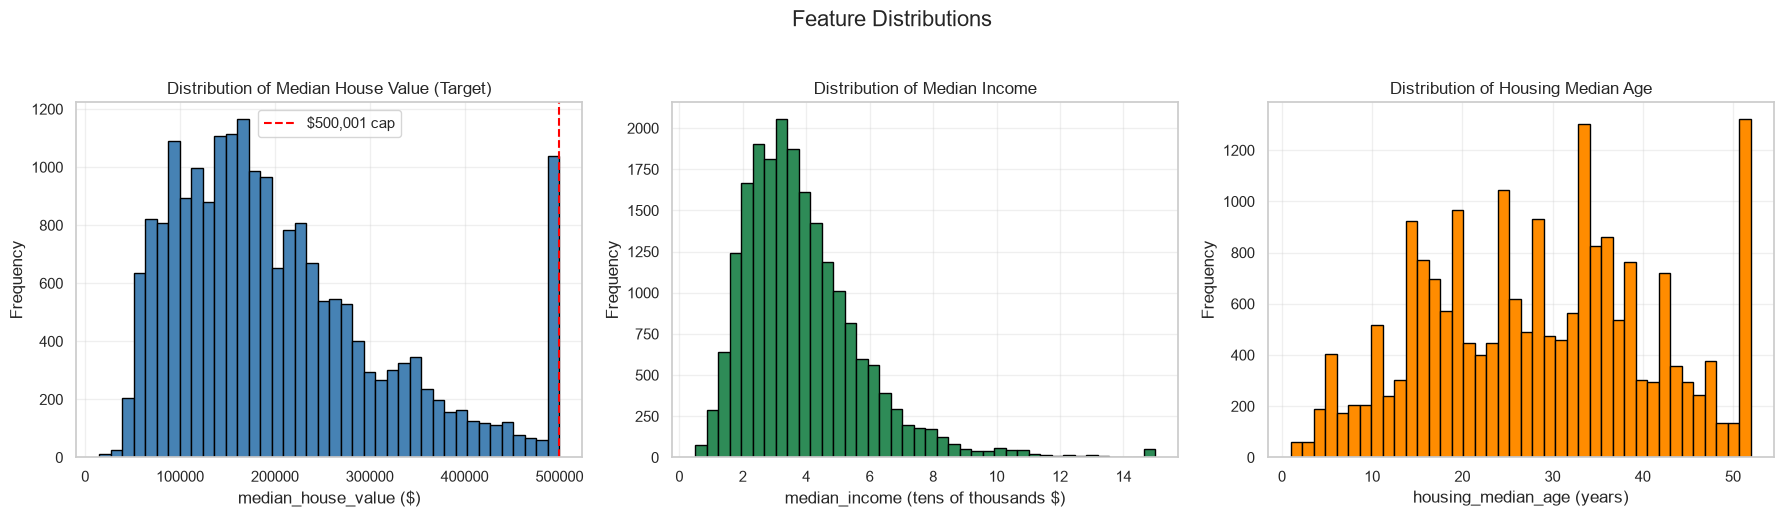

In [115]:
#Histogram

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["median_house_value"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Median House Value (Target)")
axes[0].set_xlabel("median_house_value ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(500001, color="red", linestyle="--", linewidth=1.5, label="$500,001 cap")
axes[0].legend()

axes[1].hist(df["median_income"], bins=40, color="seagreen", edgecolor="black")
axes[1].set_title("Distribution of Median Income")
axes[1].set_xlabel("median_income (tens of thousands $)")
axes[1].set_ylabel("Frequency")

axes[2].hist(df["housing_median_age"], bins=40, color="darkorange", edgecolor="black")
axes[2].set_title("Distribution of Housing Median Age")
axes[2].set_xlabel("housing_median_age (years)")
axes[2].set_ylabel("Frequency")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle("Feature Distributions", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

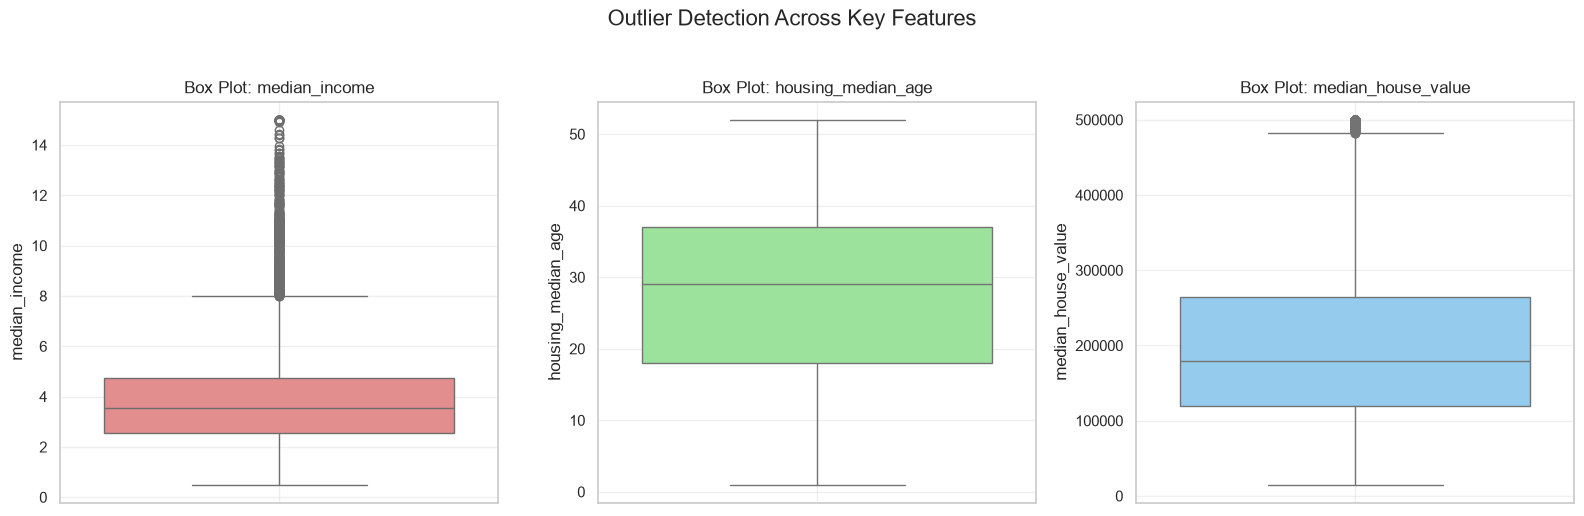

In [116]:
#Box plots

box_features = ["median_income", "housing_median_age", "median_house_value"]
colors = ["lightcoral", "lightgreen", "lightskyblue"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, c in zip(axes, box_features, colors):
    sns.boxplot(y=df[col], ax=ax, color=c)
    ax.set_title(f"Box Plot: {col}")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.suptitle("Outlier Detection Across Key Features", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

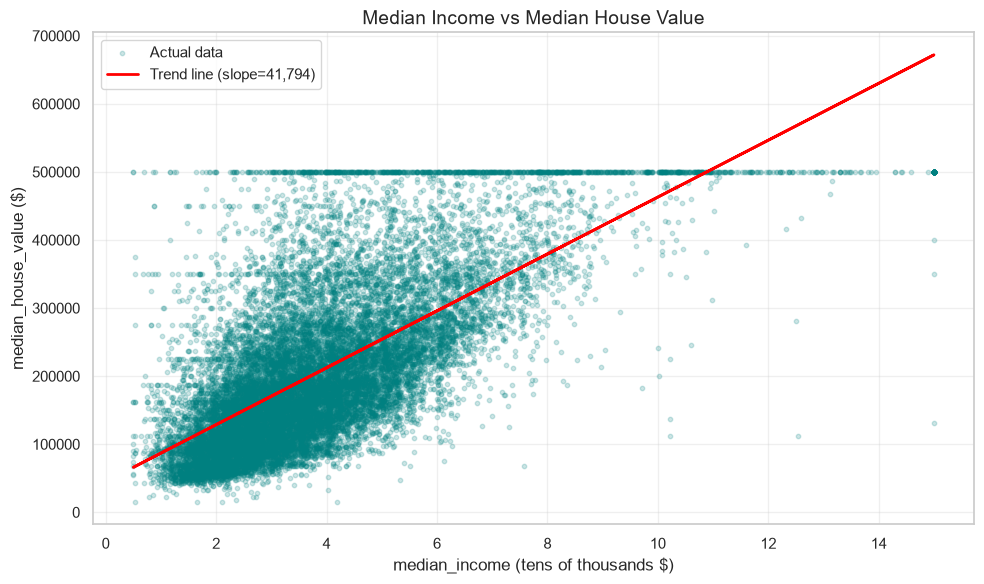

In [117]:
#Scatter plot

x = df["median_income"]
y = df["median_house_value"]

# fit a straight trend line: degree-1 polynomial
slope, intercept = np.polyfit(x, y, 1)
trend = slope * x + intercept

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.2, color="teal", s=10, label="Actual data")
plt.plot(x, trend, color="red", linewidth=2, label=f"Trend line (slope={slope:,.0f})")
plt.title("Median Income vs Median House Value", fontsize=14)
plt.xlabel("median_income (tens of thousands $)")
plt.ylabel("median_house_value ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

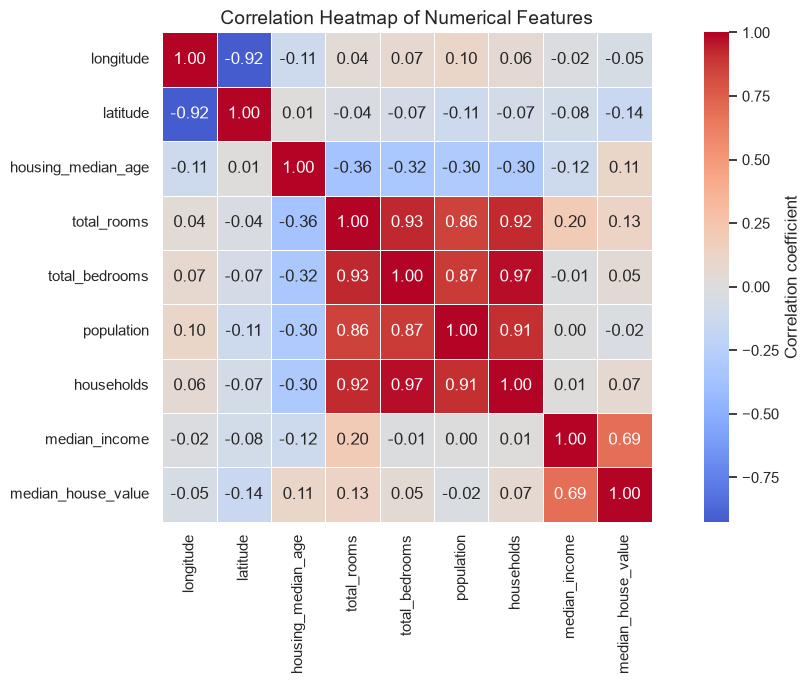

In [126]:
#Correlation heatmap

original_num = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income",
                "median_house_value"]

plt.figure(figsize=(11, 7))
corr = df[original_num].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation coefficient"})
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

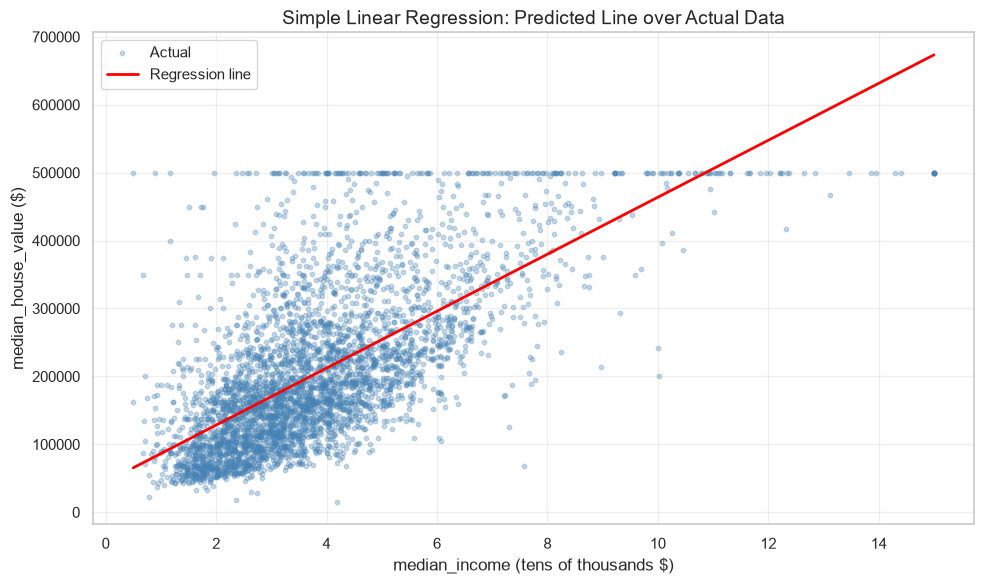

In [119]:
#Regression line plot

order = X_test["median_income"].argsort()
x_sorted = X_test["median_income"].values[order]
y_pred_sorted = model.predict(X_test).flatten()[order]

plt.figure(figsize=(10, 6))
plt.scatter(X_test["median_income"], y_test, alpha=0.3, color="steelblue", s=10, label="Actual")
plt.plot(x_sorted, y_pred_sorted, color="red", linewidth=2, label="Regression line")
plt.title("Simple Linear Regression: Predicted Line over Actual Data", fontsize=14)
plt.xlabel("median_income (tens of thousands $)")
plt.ylabel("median_house_value ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

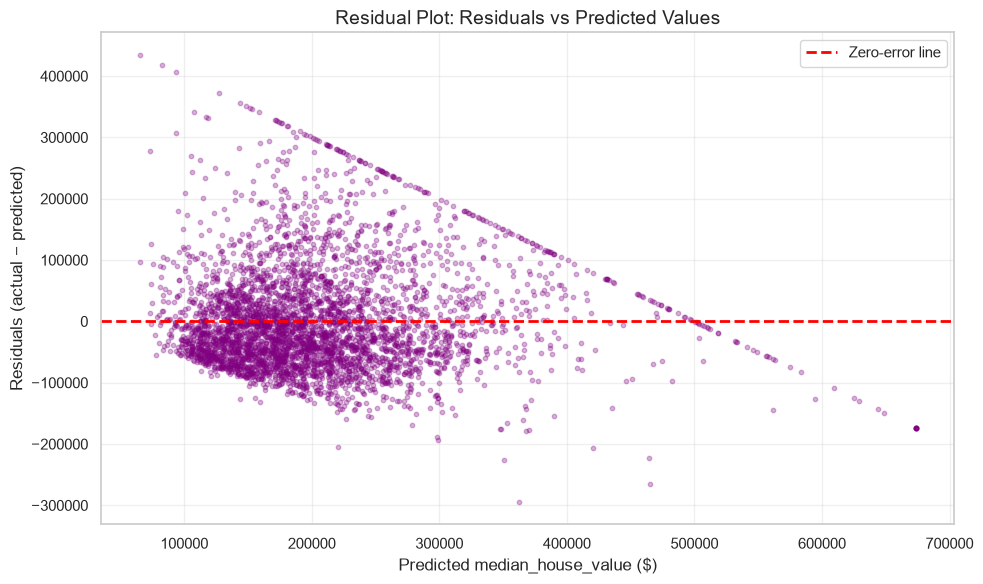

In [120]:
#residual plot

y_pred_simple = model.predict(X_test)
residuals = y_test - y_pred_simple

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals, alpha=0.3, color="purple", s=10)
plt.axhline(y=0, color="red", linestyle="--", linewidth=2, label="Zero-error line")
plt.title("Residual Plot: Residuals vs Predicted Values", fontsize=14)
plt.xlabel("Predicted median_house_value ($)")
plt.ylabel("Residuals (actual − predicted)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Visualization Portfolio Summary

This section consolidates the six required visualizations, each with a descriptive title, axis labels with units, non-default color schemes, gridlines, and legends where multiple series appear. Key data artifacts are annotated directly — notably the $500,001 cap on median_house_value, visible as a spike in the histogram and a diagonal band in the residual plot.

## Part 8 — Conclusion & Reflection

**What I learned.** This assignment took me through a complete data analysis workflow — importing and inspecting data, cleaning it, exploring it visually and statistically, and finally building and comparing regression models. More than any single technique, I learned that the workflow is iterative: cleaning is not a one-time step, and each new stage can surface problems the previous one couldn't.

**Most surprising finding.** Two things surprised me. First, that median_income alone explains almost as much of house value (R² ≈ 0.46) as five features combined — income is by far the dominant driver in California housing. Second, and more striking, that median_house_value is artificially capped at $500,001. This appears as a sharp spike in the histogram and a clean diagonal band in the residual plot, and it places a hard ceiling on how accurate any model can be.

**Challenges and how I overcame them.** My biggest challenge was that my multiple regression initially performed *worse* than the simple model (R² dropped to 0.41). I traced this to extreme outliers in my engineered ratio features — values like 1243 people per household — caused by block groups with very few households. Clipping these to sensible bounds raised R² to 0.52, finally beating the baseline. I also hit practical issues with Jupyter's kernel state: variables computed before a fix weren't updating, which taught me to run notebooks cleanly from top to bottom and to be careful about cell execution order.

**Real business context.** This kind of analysis directly supports real-estate pricing, mortgage risk assessment, and investment decisions. A lender could estimate property values from neighborhood income and density; a developer could identify undervalued areas. The caveat — which the $500,001 cap illustrates — is that a model is only as trustworthy as the data feeding it, so understanding data limitations is as important as the predictions themselves.

**What I'd do differently.** With more time, I would add the geographic features (latitude, longitude, ocean_proximity) that I left out — location clearly drives price and my linear model ignored it. I would also try models that handle non-linearity and the capped target better, such as tree-based methods, and standardize features from the start to compare their importance fairly.

**Connection to machine learning.** The statistics here *are* the foundation of ML. Correlation guided feature selection; train/test splitting is how ML measures generalization; R², MAE, and RMSE are standard model-evaluation metrics; and multicollinearity, outliers, and feature engineering are everyday concerns in real ML pipelines. Linear regression is itself one of the simplest supervised learning algorithms.